In [1]:
pip install pandas numpy scikit-learn nltk matplotlib seaborn

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 11.8 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\V.laxmi
[nltk_data]     sahithi\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [4]:
fake = pd.read_csv("C:\\Users\\V.laxmi sahithi\\Downloads\\Fake.csv\\Fake.csv")
real = pd.read_csv("C:\\Users\\V.laxmi sahithi\\Downloads\\True.csv\\True.csv")

fake['label'] = 0
real['label'] = 1

df = pd.concat([fake, real])
df = df.sample(frac=1).reset_index(drop=True)

df.head()

,title,text,subject,date,label
0,WHY PAUL MANAFORT Indictment Is Bad News For D...,"This summarization by Peter Flaherty, Presiden...",left-news,"Oct 31, 2017",0
1,"Republicans Did This, And Now Britain Is Warn...","Once again, states run by conservative Republi...",News,"April 21, 2016",0
2,Russia's Lavrov to Iran's Zarif: Moscow commit...,MOSCOW (Reuters) - Russian Foreign Minister Se...,worldnews,"October 13, 2017",1
3,DEMOCRAT REP: Sexual Assault Is A Woman’s Faul...,Wow! These Texas Democratic congresswomen are ...,politics,"Oct 19, 2017",0
4,Anti-Porn GOP Florida Lawmaker Was Just Caugh...,"The GOP has a thing for porn. In 2016, Sen. To...",News,"September 21, 2017",0


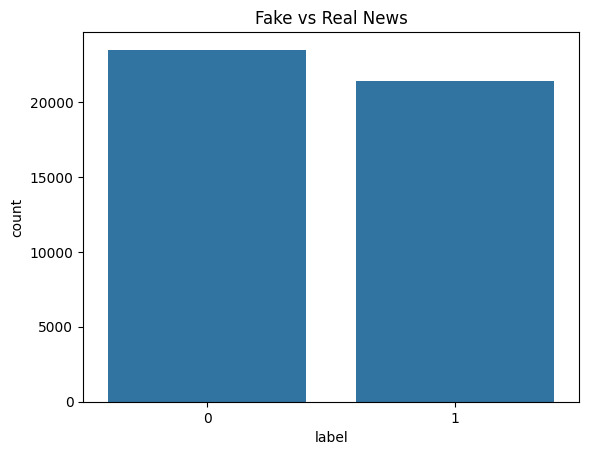

In [5]:
sns.countplot(x='label', data=df)
plt.title("Fake vs Real News")
plt.show()

In [6]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = text.lower()
    words = text.split()
    
    words = [ps.stem(word) for word in words if word not in stop_words]
    
    return ' '.join(words)

df['content'] = df['title'] + " " + df['text']
df['content'] = df['content'].apply(clean_text)

In [7]:
X = df['content']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
vectorizer = TfidfVectorizer(max_features=5000) #Term Frequency – Inverse Document Frequency

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [9]:
model = LogisticRegression()
model.fit(X_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [10]:
y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9837416481069042
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      4686
           1       0.98      0.98      0.98      4294

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



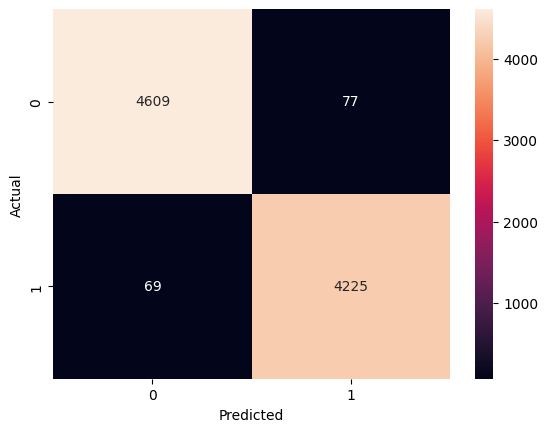

In [11]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [12]:
def predict_news(text):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    pred = model.predict(vec)
    
    return "REAL NEWS " if pred[0] == 1 else "FAKE NEWS "

# Example
print(predict_news("Government announces new education policy"))

FAKE NEWS 
